In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from transformer_lens import HookedTransformer
from huggingface_hub import login
from sae_lens import SAE

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

DATA_DIR    = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
login()

In [ ]:
LAYERS = [18, 22, 25]   #We'll use these layers coz we found these were highest during AP  
K_PER_LAYER = 40          
ALPHA = 0.01              
SAE_RELEASE = "gemma-scope-2b-pt-res-canonical"

In [ ]:
pilot = torch.load(DATA_DIR / "ioi_dataset.pt", weights_only=False) #TODO: Consolidate between notebooks for 500 and 5000 prompt versions
clean_toks    = pilot["clean_toks"].to(device)
end_positions = pilot["end_positions"].to(device)
N             = pilot["N"]
print(f"N = {N}, seq_len = {clean_toks.shape[1]}")

N = 5000, seq_len = 22


In [5]:
print("\nLoading Gemma-2-2B...")
model = HookedTransformer.from_pretrained(
    "gemma-2-2b", device=device, dtype=torch.bfloat16,
)
model.eval()
d_model = model.cfg.d_model


Loading Gemma-2-2B...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [ ]:
def extract_features_at_layer(layer: int) -> torch.Tensor: #feature activations at the END position for `layer`
    print(f"\nLayer {layer}:")
    print(f"  Loading SAE...")
    sae, _, _ = SAE.from_pretrained(
        release=SAE_RELEASE,
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=device,
    )
    sae.eval()
    d_sae = sae.cfg.d_sae
    print(f"  d_sae = {d_sae}")

    hook_name = f"blocks.{layer}.hook_resid_post"

    # We'll run the model in batches and accumulate END-position features
    feats = torch.zeros(N, d_sae, dtype=torch.float32)  # CPU storage; bf16→fp32 for stability idk was getting some weird cublas bug
    batch_size = 32

    print(f"  Running forward passes (batch_size={batch_size})...")
    with torch.no_grad():
        for i in range(0, N, batch_size):
            batch_toks = clean_toks[i:i + batch_size]
            batch_ends = end_positions[i:i + batch_size]

            cache = {}
            def hook_fn(act, hook):
                cache["resid"] = act
                return act

            _ = model.run_with_hooks(batch_toks, fwd_hooks=[(hook_name, hook_fn)])
            resid = cache["resid"]                           # [B, seq, d_model]

            # Index out the END position per prompt
            batch_idx = torch.arange(batch_toks.shape[0], device=device)
            resid_end = resid[batch_idx, batch_ends]         # [B, d_model]

            # Project through the SAE to get feature acts
            sae_acts = sae.encode(resid_end.to(sae.W_enc.dtype))  # [B, d_sae]
            feats[i:i + batch_size] = sae_acts.float().cpu()

    del sae
    torch.cuda.empty_cache()
    return feats

features_per_layer = {L: extract_features_at_layer(L) for L in LAYERS}


Layer 18:
  Loading SAE...


layer_18/width_16k/average_l0_74/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

/tmp/ipykernel_5412/2725910640.py:5: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, _, _ = SAE.from_pretrained(


  d_sae = 16384
  Running forward passes (batch_size=32)...

Layer 22:
  Loading SAE...


layer_22/width_16k/average_l0_72/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

  d_sae = 16384
  Running forward passes (batch_size=32)...

Layer 25:
  Loading SAE...


layer_25/width_16k/average_l0_116/params(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

  d_sae = 16384
  Running forward passes (batch_size=32)...


In [ ]:
print(f"\nSelecting top-{K_PER_LAYER} features per layer by activation variance...")

selected = {}    # layer => list of feature indices
selected_acts = {} 

for L in LAYERS:
    feats = features_per_layer[L]                 
    var = feats.var(dim=0)                         
    top_idx = torch.topk(var, K_PER_LAYER).indices  
    selected[L] = top_idx.tolist()
    selected_acts[L] = feats[:, top_idx]           
    print(f"  Layer {L}: selected {K_PER_LAYER} features. "
          f"Variance range: {var[top_idx].min():.3f} to {var[top_idx].max():.3f}")


Selecting top-40 features per layer by activation variance...
  Layer 18: selected 40 features. Variance range: 27.167 to 269.444
  Layer 22: selected 40 features. Variance range: 72.862 to 409.705
  Layer 25: selected 40 features. Variance range: 156.977 to 2090.505


In [ ]:
print("\nBinarizing and concatenating...")
binary_per_layer = {L: (selected_acts[L] > 0).to(torch.int8) for L in LAYERS}

X_binary = torch.cat([binary_per_layer[L] for L in LAYERS], dim=1).numpy()
total_features = X_binary.shape[1]

col_to_layer = []
col_to_feat  = []
for L in LAYERS:
    for f_idx in selected[L]:
        col_to_layer.append(L)
        col_to_feat.append(f_idx)

print(f"X_binary shape: {X_binary.shape}, dtype: {X_binary.dtype}")
print(f"Sparsity (fraction of zeros): {(X_binary == 0).mean():.3f}")


Binarizing and concatenating...
X_binary shape: (5000, 120), dtype: int8
Sparsity (fraction of zeros): 0.471


In [9]:
col_var = X_binary.var(axis=0)
nonconstant = col_var > 0
if not nonconstant.all():
    n_dropped = (~nonconstant).sum()
    print(f"⚠ Dropping {n_dropped} constant columns (no variance)")
    X_binary = X_binary[:, nonconstant]
    col_to_layer = [l for l, ok in zip(col_to_layer, nonconstant) if ok]
    col_to_feat  = [f for f, ok in zip(col_to_feat,  nonconstant) if ok]

print(f"Final X_binary shape: {X_binary.shape}")

⚠ Dropping 5 constant columns (no variance)
Final X_binary shape: (5000, 115)


In [ ]:
print(f"\nRunning PC algorithm (alpha={ALPHA}, chi-squared)...")
print("  This may take a couple of minutes for ~120 binary variables on N=500...")

cg = pc(
    data=X_binary,
    alpha=ALPHA,
    indep_test=chisq,
    show_progress=True,
)

#This is what the docs say:
# causal-learn returns a CausalGraph object. Extract the adjacency information.
# The graph attribute is a numpy array of shape [n, n] where:
#   G[i, j] = -1, G[j, i] = 1   means i → j (directed)
#   G[i, j] = -1, G[j, i] = -1  means i — j (undirected)
#   G[i, j] = 0,  G[j, i] = 0   means no edge

G_matrix = cg.G.graph                                
n = G_matrix.shape[0]
print(f"\nLearned graph has {n} nodes.")

# Count edges
n_directed = 0
n_undirected = 0
for i in range(n):
    for j in range(i + 1, n):
        if G_matrix[i, j] == -1 and G_matrix[j, i] == 1:
            n_directed += 1
        elif G_matrix[i, j] == 1 and G_matrix[j, i] == -1:
            n_directed += 1
        elif G_matrix[i, j] == -1 and G_matrix[j, i] == -1:
            n_undirected += 1
print(f"  Directed edges:   {n_directed}")
print(f"  Undirected edges: {n_undirected}")



Running PC algorithm (alpha=0.01, chi-squared)...
  This may take a couple of minutes for ~120 binary variables on N=500...


  0%|          | 0/115 [00:00<?, ?it/s]


Learned graph has 115 nodes.
  Directed edges:   352
  Undirected edges: 14


In [11]:
print("\nApplying layer prior (shallow → deep)...")
edges = []   # list of (parent_col, child_col, was_oriented_by_prior)

for i in range(n):
    for j in range(i + 1, n):
        L_i, L_j = col_to_layer[i], col_to_layer[j]
        edge_present = (G_matrix[i, j] != 0) or (G_matrix[j, i] != 0)
        if not edge_present:
            continue

        if L_i != L_j:
            # Cross-layer: orient from shallow to deep
            parent, child = (i, j) if L_i < L_j else (j, i)
            edges.append((parent, child, True))
        else:
            # Within-layer: respect PC's orientation if present, else mark undirected
            if G_matrix[i, j] == -1 and G_matrix[j, i] == 1:
                edges.append((i, j, False))
            elif G_matrix[i, j] == 1 and G_matrix[j, i] == -1:
                edges.append((j, i, False))
            else:
                edges.append((i, j, False))   # undirected; we just record one direction

n_cross_layer = sum(1 for _, _, by_prior in edges if by_prior)
n_within_layer = len(edges) - n_cross_layer
print(f"  Cross-layer edges (oriented by prior): {n_cross_layer}")
print(f"  Within-layer edges:                    {n_within_layer}")


Applying layer prior (shallow → deep)...
  Cross-layer edges (oriented by prior): 237
  Within-layer edges:                    129


In [ ]:
torch.save({
    "G_matrix":     G_matrix,                
    "edges":        edges,                   
    "col_to_layer": col_to_layer,
    "col_to_feat":  col_to_feat,
    "selected":     selected,
    "X_binary":     X_binary,
    "alpha":        ALPHA,
    "layers":       LAYERS,
    "k_per_layer":  K_PER_LAYER,
}, DATA_DIR / "pc_learned_graph.pt")
print(f"\nSaved to {DATA_DIR / 'pc_learned_graph.pt'}")


Saved to /workspace/Independence-Is-All-You-Need/data/pc_learned_graph.pt


Saved figure to /workspace/Independence-Is-All-You-Need/figures/pc_learned_graph.png


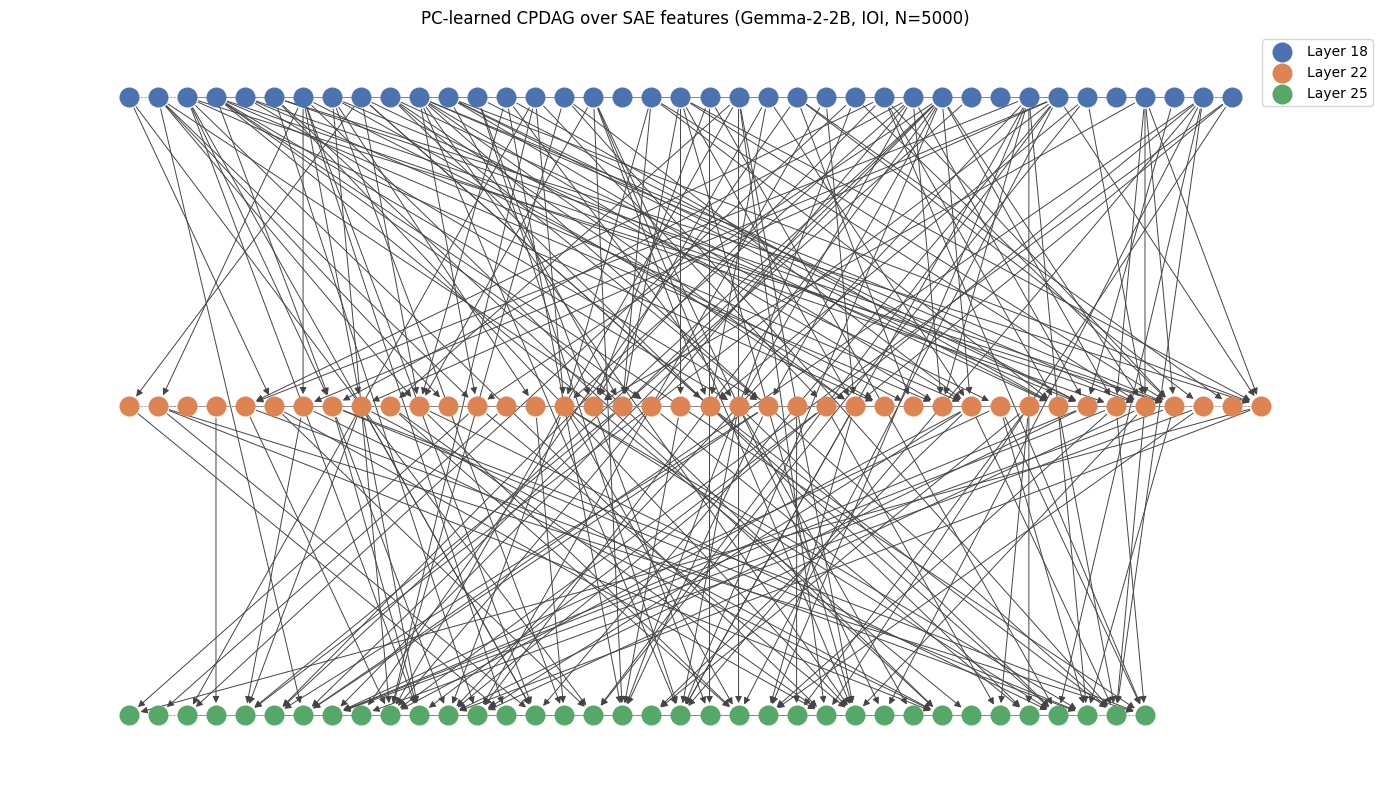

In [13]:
g = nx.DiGraph()
for col in range(n):
    g.add_node(col, layer=col_to_layer[col], feat=col_to_feat[col])

for parent, child, by_prior in edges:
    g.add_edge(parent, child, by_prior=by_prior)

# Layered layout: x by within-layer index, y by layer depth
pos = {}
for L_idx, L in enumerate(LAYERS):
    cols_in_layer = [c for c in range(n) if col_to_layer[c] == L]
    for x_idx, c in enumerate(cols_in_layer):
        pos[c] = (x_idx, -L_idx)

fig, ax = plt.subplots(figsize=(14, 8))

# Draw nodes coloured by layer
layer_colours = {LAYERS[0]: "#4c72b0", LAYERS[1]: "#dd8452", LAYERS[2]: "#55a868"}
for L in LAYERS:
    cols = [c for c in range(n) if col_to_layer[c] == L]
    nx.draw_networkx_nodes(g, pos, nodelist=cols,
                           node_color=layer_colours[L], node_size=180,
                           label=f"Layer {L}", ax=ax)

# Edges: solid for prior-oriented (cross-layer), dashed for within-layer
prior_edges = [(p, c) for p, c, b in edges if b]
within_edges = [(p, c) for p, c, b in edges if not b]
nx.draw_networkx_edges(g, pos, edgelist=prior_edges,  edge_color="#444444",
                       arrows=True, arrowsize=10, width=0.7, ax=ax)
nx.draw_networkx_edges(g, pos, edgelist=within_edges, edge_color="#888888",
                       style="dashed", arrows=False, width=0.5, ax=ax)

ax.set_title(f"PC-learned CPDAG over SAE features (Gemma-2-2B, IOI, N={N})")
ax.legend(loc="upper right")
ax.axis("off")
plt.tight_layout()
fig_path = FIGURES_DIR / "pc_learned_graph.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

In [ ]:
print("\nGraph diagnostics:")
print(f"  Total edges: {len(edges)}")
print(f"  Edge density: {len(edges) / (n * (n - 1) / 2):.1%}")


from collections import Counter
edge_counts = Counter()
for p, c, _ in edges:
    L_p, L_c = col_to_layer[p], col_to_layer[c]
    edge_counts[(min(L_p, L_c), max(L_p, L_c))] += 1
print("  Edges by layer pair:")
for (L1, L2), n_e in sorted(edge_counts.items()):
    label = f"layer {L1} → layer {L2}" if L1 != L2 else f"within layer {L1}"
    print(f"    {label}: {n_e}")


print("\n  Searching for v-structures (A → C ← B, no A-B edge)...")
adjacency = {i: set() for i in range(n)}
parents   = {i: set() for i in range(n)}
for p, c, _ in edges:
    parents[c].add(p)
    adjacency[p].add(c)
    adjacency[c].add(p)

v_structures = []
for c in range(n):
    parent_list = sorted(parents[c])
    for i, A in enumerate(parent_list):
        for B in parent_list[i + 1:]:
            if B not in adjacency[A]:   # A and B not adjacent
                v_structures.append((A, c, B))

print(f"  Found {len(v_structures)} v-structures.")
if v_structures[:5]:
    print("  First 5:")
    for A, C, B in v_structures[:5]:
        L_A = col_to_layer[A]; L_C = col_to_layer[C]; L_B = col_to_layer[B]
        f_A = col_to_feat[A];  f_C = col_to_feat[C];  f_B = col_to_feat[B]
        print(f"    L{L_A}_F{f_A}  →  L{L_C}_F{f_C}  ←  L{L_B}_F{f_B}")


Graph diagnostics:
  Total edges: 366
  Edge density: 5.6%
  Edges by layer pair:
    within layer 18: 69
    layer 18 → layer 22: 99
    layer 18 → layer 25: 66
    within layer 22: 29
    layer 22 → layer 25: 72
    within layer 25: 31

  Searching for v-structures (A → C ← B, no A-B edge)...
  Found 599 v-structures.
  First 5:
    L18_F4651  →  L18_F9378  ←  L18_F7768
    L18_F4651  →  L18_F9378  ←  L18_F61
    L18_F4651  →  L18_F9378  ←  L18_F1145
    L18_F7768  →  L18_F9378  ←  L18_F2297
    L18_F7768  →  L18_F9378  ←  L18_F61
